<a href="https://colab.research.google.com/github/siinwook/Deep-Learning-from-Scratch/blob/main/ch05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install import_ipynb
import sys, import_ipynb

from google.colab import drive
drive.mount('/content/drive')

%cd "__path__"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ex. backpropagation with computational graph : Apple and Orange

In [ ]:
class MulLayer:
  def __init__(self):
    self.x = None
    self.y = None

  def forward(self,x,y):
    self.x = x
    self.y = y
    out = x * y

    return out

  def backward(self, dout):
    dx = dout * self.y
    dy = dout * self.x

    return dx, dy

In [ ]:
class AddLayer:
  def __init__(self):
    pass

  def forward(self, x, y):
    return x+y

  def backward(self, dout):
    dx = dout
    dy = dout

    return dx, dy

In [ ]:
apple = 100
apple_num = 2
orange = 150
orange_num = 3
tax = 1.1

mul_apple_layer = MulLayer()
mul_orange_layer = MulLayer()
add_apple_orange_layer = AddLayer()
mul_tax_layer = MulLayer()

#forwardpropagation
apple_price = mul_apple_layer.forward(apple, apple_num)
orange_price = mul_orange_layer.forward(orange, orange_num)
all_price = add_apple_orange_layer.forward(apple_price, orange_price)
price = mul_tax_layer.forward(all_price, tax)

#backpropagation
dprice = 1
dall_price, dtax = mul_tax_layer.backward(dprice)
dapple_price, dorange_price = add_apple_orange_layer.backward(dall_price)
dorange, dorange_num = mul_orange_layer.backward(dorange_price)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)

print(price)
print(dapple_num, dapple, dorange, dorange_num, dtax)

715.0000000000001
110.00000000000001 2.2 3.3000000000000003 165.0 650


Relu layer

In [ ]:
class Relu:
  def __init__(self):
    self.mask = None # is zero or negative

  def forward(self,x):
    self.mask = (x<=0)
    out = x.copy()
    out[self.mask]=0

    return out

  def backward(self,dout):
    dout[self.mask] = 0
    dx = dout

    return dx

Sigmoid layer

In [ ]:
class Sigmoid:
  def _init__(self):
    self.out = None

  def forward(self, x):
    out = 1 / (1+np.exp(-x))
    self.out = out

    return out

  def backward(self, dout):
    dx = dout * self.out * (1-self.out) #d/dx[sigmoid(x)] = sigmoid(x) * (1 - sigmoid(x))

    return dx

Affine layer

In [ ]:
class Affine:
  def __init__(self,W,b):
    self.W = W
    self.b = b
    self.x = None
    self.dW = None
    self.db = None

    self.original_x_shape = None #for img(4-dim)

  def forward(self,x):
    self.original_x_shape = x.shape
    x = x.reshape(x.shape[0],-1)
    self.x = x

    out = np.dot(x,self.W) + self.b

    return out

  def backward(self, dout):
    dx = np.dot(dout, self.W.T) #dx = dout dot W.T
    self.dW = np.dot(self.x.T, dout) #dW = x.T dot dout
    self.db = np.sum(dout,axis=0) #db = sum(dout)

    dx = dx.reshape(*self.original_x_shape)
    return dx

Softmax with Loss layer

In [ ]:
from functions import *
class SoftmaxWithLoss:
  def __init__(self):
    self.loss = None
    self.y = None
    self.t = None

  def forward(self,x,t):
    self.t = t
    self.y = softmax(x)
    self.loss = cross_entropy_error(self.y, self.t)

    return self.loss

  def backward(self, dout):
    batch_size = self.t.shape[0]
    dx = (self.y - self.t) / batch_size

    return dx

2-layer network

In [ ]:
from functions import *
from collections import OrderedDict

class TwoLayerNet:
  def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
    self.params = {}
    self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
    self.params['b1'] = weight_init_std * np.random.randn(hidden_size)
    self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
    self.params['b2'] = weight_init_std * np.random.randn(output_size)

    self.layers = OrderedDict()
    self.layers['Affine1'] = Affine(self.params['W1'], self.params['b1'])
    self.layers['Relu1'] = Relu()
    self.layers['Affine2'] = Affine(self.params['W2'], self.params['b2'])

    self.Lastlayer = SoftmaxWithLoss()

  def predict(self,x):
    for layers in self.layers.values():
      x = layers.forward(x)

    return x

  def loss(self, x, t):
    y = self.predict(x)
    return self.Lastlayer.forward(y,t)

  def accuracy(self,x,t):
    y = self.predict(x)
    y = np.argmax(y, axis=1)
    if t.ndim != 1:
      t = np.argmax(t, axis=1)

    accuracy = np.sum((y==t).astype(int)) / float(x.shape[0])
    return accuracy

  def numerical_gradient(self, x, t):
    loss_W = lambda W: self.loss(x,t)

    grads={}
    grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
    grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
    grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
    grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

    return grads

  def gradient(self, x, t):
    #forwardpropagation
    self.loss(x,t)

    #backwardpropagation
    dout = 1
    dout = self.Lastlayer.backward(dout)

    layers = list(self.layers.values())
    layers.reverse()
    for layer in layers:
      dout = layer.backward(dout)

    grads = {}
    grads['W1'] = self.layers['Affine1'].dW
    grads['b1'] = self.layers['Affine1'].db
    grads['W2'] = self.layers['Affine2'].dW
    grads['b2'] = self.layers['Affine2'].db

    return grads

mini batch training

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import tqdm

(x_train, t_train), (x_test, t_test) = mnist.load_data()
x_train = x_train.reshape(60000,784)
x_test = x_test.reshape(10000,784)
x_train = x_train/255.0
x_test = x_test/255.0
t_train = to_categorical(t_train, 10).astype(int) # one-hot encoding
t_test = to_categorical(t_test, 10).astype(int)

train_loss_list = []
train_acc_list = []
test_acc_list = []

#hyper parameter
iters_num = 30000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.001

network = TwoLayerNet(input_size = 784, hidden_size = 50, output_size=10)

iter_per_epoch = max(train_size / batch_size, 1)

for i in tqdm.tqdm(range(iters_num)):
  batch_mask = np.random.choice(train_size,batch_size)
  x_batch = x_train[batch_mask]
  t_batch = t_train[batch_mask]

  grad = network.gradient(x_batch, t_batch) # numerical_gradient -> gradient

  for key in ('W1', 'b1', 'W2', 'b2'):
    network.params[key] -= learning_rate * grad[key]

  loss = network.loss(x_batch, t_batch)
  train_loss_list.append(loss)

  # accuracy per epoch (epoch: # of iteration using whole set)
  if i % iter_per_epoch == 0:
    train_acc = network.accuracy(x_train, t_train)
    test_acc = network.accuracy(x_test, t_test)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))

  0%|          | 15/30000 [00:00<21:42, 23.03it/s] 

train acc, test acc | 0.10461666666666666, 0.1033


  2%|▏         | 605/30000 [00:05<04:23, 111.68it/s]

train acc, test acc | 0.10761666666666667, 0.1055


  4%|▍         | 1252/30000 [00:08<02:31, 190.00it/s]

...

 96%|█████████▌| 28851/30000 [02:31<00:07, 150.69it/s]

train acc, test acc | 0.8811666666666667, 0.8845


 98%|█████████▊| 29468/30000 [02:33<00:02, 195.64it/s]

train acc, test acc | 0.8822166666666666, 0.8866


100%|██████████| 30000/30000 [02:34<00:00, 193.59it/s]


train / test accuracy

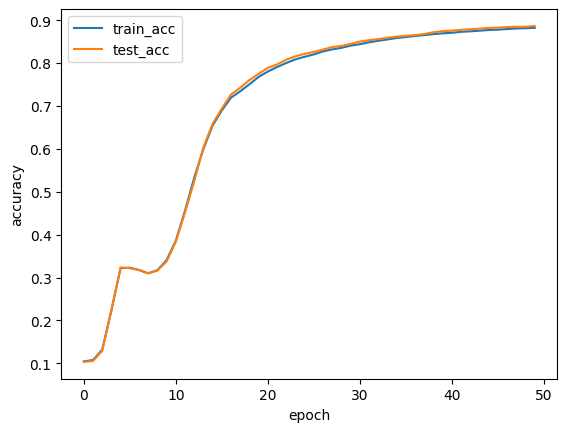

In [ ]:
plt.plot(train_acc_list)
plt.plot(test_acc_list)
plt.legend(['train_acc','test_acc'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

loss

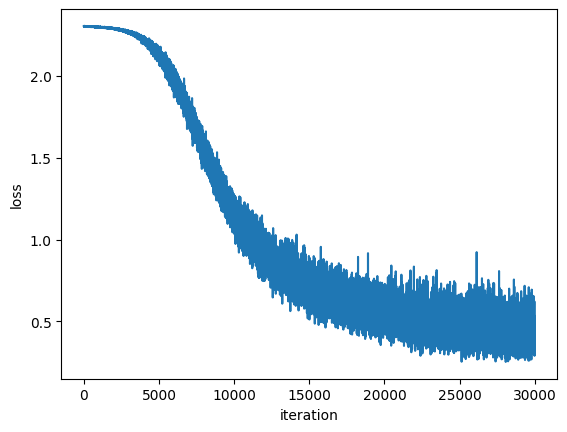

In [ ]:
plt.plot(train_loss_list)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.show()